# Notebook 03 - Federated Learning (Flower + FedProx)

**Tujuan:** melatih model global menggunakan federated learning dengan data Non-IID.

**Ringkas alur:** definisi client, training lokal per round, agregasi FedProx,
evaluasi global di gabungan test set semua node, dan visualisasi confusion matrix.

**Catatan evaluasi:** hasil global dibandingkan dengan model standalone untuk menunjukkan
trade-off generalisasi lintas node vs performa lokal.


In [1]:
import flwr as fl
import torch
import torch.nn as nn
import numpy as np
import os
import pickle
from torch.utils.data import DataLoader, TensorDataset
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.common import Context, parameters_to_ndarrays
from flwr.server.strategy import FedProx
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

SAVE_DIR = "../datasets/preprocessed"
MODEL_DIR = "../models"
NUM_FEATURES = 68
NUM_CLASSES = 11

print("Flower version:", fl.__version__)

Flower version: 1.29.0


In [2]:
class ANN(nn.Module):
    """
    Arsitektur ANN identik di semua node sesuai requirement FL:
    setiap node menggunakan algoritma yang sama.
    Input(68) -> 256 -> 128 -> 64 -> Output(11)
    """
    def __init__(self, input_dim, num_classes):
        super(ANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [3]:
def get_weights(model):
    """Ekstrak bobot model sebagai list numpy array untuk dikirim ke server."""
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

def set_weights(model, weights):
    """Load bobot dari server ke model lokal."""
    params_dict = zip(model.state_dict().keys(), weights)
    state_dict = {k: torch.tensor(v) for k, v in params_dict}
    model.load_state_dict(state_dict, strict=True)

def make_dataloader(X, y, batch_size=1024, shuffle=True):
    """Buat DataLoader dari numpy array."""
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

def load_node_data(node_id):
    """Load data preprocessed untuk node tertentu dari disk."""
    X_train = np.load(f"{SAVE_DIR}/node{node_id}_X_train.npy")
    X_test = np.load(f"{SAVE_DIR}/node{node_id}_X_test.npy")
    y_train = np.load(f"{SAVE_DIR}/node{node_id}_y_train.npy")
    y_test = np.load(f"{SAVE_DIR}/node{node_id}_y_test.npy")
    return X_train, X_test, y_train, y_test

In [4]:
class IDSClient(fl.client.NumPyClient):
    """
    Flower client untuk tiap node IDS.
    Mengimplementasikan tiga method wajib:
    - get_parameters: kirim bobot model ke server
    - fit: training lokal dan kirim bobot hasil training ke server
    - evaluate: evaluasi global model di data lokal
    """
    def __init__(self, node_id):
        self.node_id = node_id
        # device di-resolve di dalam client karena Ray subprocess
        # tidak selalu punya akses GPU
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        X_train, X_test, y_train, y_test = load_node_data(node_id)
        self.train_loader = make_dataloader(X_train, y_train)
        self.test_loader = make_dataloader(X_test, y_test, shuffle=False)
        self.num_train = len(X_train)

    def _get_criterion(self):
        """
        Node 3 pakai class weighting untuk menangani imbalance ekstrem.
        Bot=15x dan Web Attack=12x dipilih berdasarkan hasil tuning.
        Node 1 dan 2 pakai CrossEntropyLoss standar.
        """
        if self.node_id == 3:
            w = torch.ones(NUM_CLASSES)
            w[1] = 15.0   # Bot
            w[10] = 12.0  # Web Attack
            return nn.CrossEntropyLoss(weight=w.to(self.device))
        return nn.CrossEntropyLoss()

    def get_parameters(self, config):
        """Kirim bobot model inisialisasi ke server saat round pertama."""
        model = ANN(NUM_FEATURES, NUM_CLASSES).to(self.device)
        return get_weights(model)

    def fit(self, parameters, config):
        """
        Training lokal satu epoch per round FL.
        FedProx menambahkan proximal term ke loss function
        untuk mencegah model lokal drift terlalu jauh dari global model.
        mu=0.1 dipilih sebagai nilai moderat yang menjaga stabilitas
        tanpa terlalu membatasi adaptasi lokal.
        """
        model = ANN(NUM_FEATURES, NUM_CLASSES).to(self.device)
        set_weights(model, parameters)

        # simpan salinan global model untuk proximal term
        global_model = ANN(NUM_FEATURES, NUM_CLASSES).to(self.device)
        set_weights(global_model, parameters)
        global_model.eval()

        proximal_mu = config.get("proximal_mu", 0.1)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = self._get_criterion()

        model.train()
        for _ in range(1):
            for X_batch, y_batch in self.train_loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                optimizer.zero_grad()
                output = model(X_batch)
                loss = criterion(output, y_batch)

                # proximal term: hukum model lokal jika bobotnya
                # drift terlalu jauh dari global model
                proximal_term = 0.0
                for w, w_global in zip(model.parameters(), global_model.parameters()):
                    proximal_term += ((w - w_global.detach()) ** 2).sum()
                loss += (proximal_mu / 2) * proximal_term

                loss.backward()
                optimizer.step()

        return get_weights(model), self.num_train, {}

    def evaluate(self, parameters, config):
        """Evaluasi global model di test set lokal, return loss dan accuracy."""
        model = ANN(NUM_FEATURES, NUM_CLASSES).to(self.device)
        set_weights(model, parameters)
        model.eval()

        criterion = nn.CrossEntropyLoss()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in self.test_loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                total_loss += loss.item()
                preds = torch.argmax(output, dim=1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        accuracy = correct / total
        avg_loss = total_loss / len(self.test_loader)
        return avg_loss, total, {"accuracy": accuracy}

In [5]:
# mapping partition-id Flower (0,1,2) ke node_id kita (1,2,3)
NODE_MAPPING = {0: 1, 1: 2, 2: 3}

def client_fn(context):
    """Factory function yang dipanggil Flower untuk membuat client baru."""
    partition_id = context.node_config["partition-id"]
    node_id = NODE_MAPPING[partition_id]
    return IDSClient(node_id).to_client()

In [6]:
# storage untuk simpan bobot global tiap round
global_weights_per_round = []

class FedProxWithSave(FedProx):
    """
    FedProx dengan tambahan penyimpanan bobot global tiap round.
    FedProx dipilih dibanding FedAvg karena lebih stabil untuk Non-IID:
    proximal term mencegah client drift yang menyebabkan divergensi agregasi.
    proximal_mu=0.1 memberikan constraint moderat pada local optimization.
    """
    def aggregate_fit(self, server_round, results, failures):
        aggregated_params, metrics = super().aggregate_fit(
            server_round, results, failures
        )
        if aggregated_params is not None:
            weights = parameters_to_ndarrays(aggregated_params)
            global_weights_per_round.append((server_round, weights))
            print(f"Round {server_round}: bobot global tersimpan")
        return aggregated_params, metrics

def server_fn(context: Context):
    """
    Konfigurasi server FL.
    30 rounds dipilih untuk memberi cukup waktu konvergensi
    dengan Non-IID yang ekstrem antar node.
    """
    strategy = FedProxWithSave(
        fraction_fit=1.0,        # semua client ikut training tiap round
        fraction_evaluate=1.0,   # semua client ikut evaluasi tiap round
        min_fit_clients=3,       # minimal 3 client untuk training
        min_evaluate_clients=3,  # minimal 3 client untuk evaluasi
        min_available_clients=3, # tunggu sampai 3 client tersedia
        proximal_mu=0.1,         # koefisien proximal term FedProx
    )
    config = ServerConfig(num_rounds=30)
    return ServerAppComponents(config=config, strategy=strategy)

server = ServerApp(server_fn=server_fn)
client = fl.client.ClientApp(client_fn=client_fn)

# jalankan simulasi FL di satu mesin
# num_cpus=4 per client memastikan hanya satu client aktif dalam satu waktu
# karena total CPU lo 16 thread, ini mencegah memory contention
history = fl.simulation.run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=3,
    backend_config={
        "client_resources": {
            "num_cpus": 4,
            "num_gpus": 0.0,
        }
    },
)

print(f"\nTotal round tersimpan: {len(global_weights_per_round)}")

2026-05-23 15:12:36,331	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=30, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
/home/willtanoe/micromamba/envs/vel/lib/python3.10/site-packages/opentelemetry/util/_importlib_metadata.py:32: DeprecationWarning: SelectableGroups dict interface is deprecated. Use select.
  return EntryPoints(ep for group_eps in eps.values() for ep in group_eps)
/home/willtanoe/micromamba/envs/vel/lib/python3.10/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behav

Round 1: bobot global tersimpan


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


Round 2: bobot global tersimpan


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


...

Round 29: bobot global tersimpan


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 30]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


Round 30: bobot global tersimpan


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 30 round(s) in 233.96s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.9991897378635223
INFO :      		round 2: 0.8012790470521639
INFO :      		round 3: 0.6592349141981267
INFO :      		round 4: 0.5736923011440968
INFO :      		round 5: 0.5625715691933086
INFO :      		round 6: 0.4659253573612071
INFO :      		round 7: 0.4869710839094595
INFO :      		round 8: 0.4177623684401754
INFO :      		round 9: 0.39655722437998914
INFO :      		round 10: 0.3723500595707614
INFO :      		round 11: 0.3392649694777348
INFO :      		round 12: 0.3061063316798121
INFO :      		round 13: 0.32013681989650633
INFO :      		round 14: 0.289915278472434
INFO :      		round 15: 0.2999118736367833
INFO :      		round 16: 0.3007695375972143
INFO :      		round 17: 0.3352934552006489
INFO :      		round 18: 0.32281922596494556
INFO :      		round 19: 0.2891063047541205


Total round tersimpan: 30


In [7]:
# load label encoder
with open(f"{SAVE_DIR}/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

# load bobot global model dari round terakhir ke dalam ANN
_, final_weights = global_weights_per_round[-1]
global_model = ANN(NUM_FEATURES, NUM_CLASSES)
set_weights(global_model, final_weights)
global_model = global_model.to(
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)
global_model.eval()

print("Global model berhasil diload dari round terakhir.")

Global model berhasil diload dari round terakhir.


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate_global(model, X_test, y_test, device):
    """Evaluasi model di test set, return prediksi dan label asli."""
    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_tensor = torch.tensor(y_test, dtype=torch.long)
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=1024, shuffle=False)

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            preds = torch.argmax(output, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return np.array(all_preds), np.array(all_labels)

# evaluasi global model di test set semua node digabung
all_preds = []
all_labels = []

for node_id in [1, 2, 3]:
    X_test = np.load(f"{SAVE_DIR}/node{node_id}_X_test.npy")
    y_test = np.load(f"{SAVE_DIR}/node{node_id}_y_test.npy")
    preds, labels = evaluate_global(global_model, X_test, y_test, device)
    all_preds.extend(preds)
    all_labels.extend(labels)
    print(f"Node {node_id} selesai dievaluasi.")

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

present_classes = np.unique(all_labels)
present_names = le.classes_[present_classes]

print("\n=== Evaluasi Global Model (semua node) ===\n")
print(classification_report(
    all_labels, all_preds,
    labels=present_classes,
    target_names=present_names,
    digits=4,
    zero_division=0
))

Node 1 selesai dievaluasi.
Node 2 selesai dievaluasi.
Node 3 selesai dievaluasi.

=== Evaluasi Global Model (semua node) ===

                  precision    recall  f1-score   support

          BENIGN     0.9566    0.9862    0.9712    290696
             Bot     0.0000    0.0000    0.0000       391
            DDoS     0.7514    0.9775    0.8497     25605
   DoS GoldenEye     0.8669    0.3953    0.5430      2059
        DoS Hulk     0.9875    0.7268    0.8373     46025
DoS Slowhttptest     0.9186    0.7182    0.8061      1100
   DoS slowloris     0.8643    0.2968    0.4419      1159
     FTP-Patator     0.0000    0.0000    0.0000      1587
        PortScan     0.9816    0.9893    0.9854     31761
     SSH-Patator     0.0000    0.0000    0.0000      1179
      Web Attack     0.4333    0.8945    0.5838       436

        accuracy                         0.9426    401998
       macro avg     0.6146    0.5441    0.5471    401998
    weighted avg     0.9401    0.9426    0.9370    401998



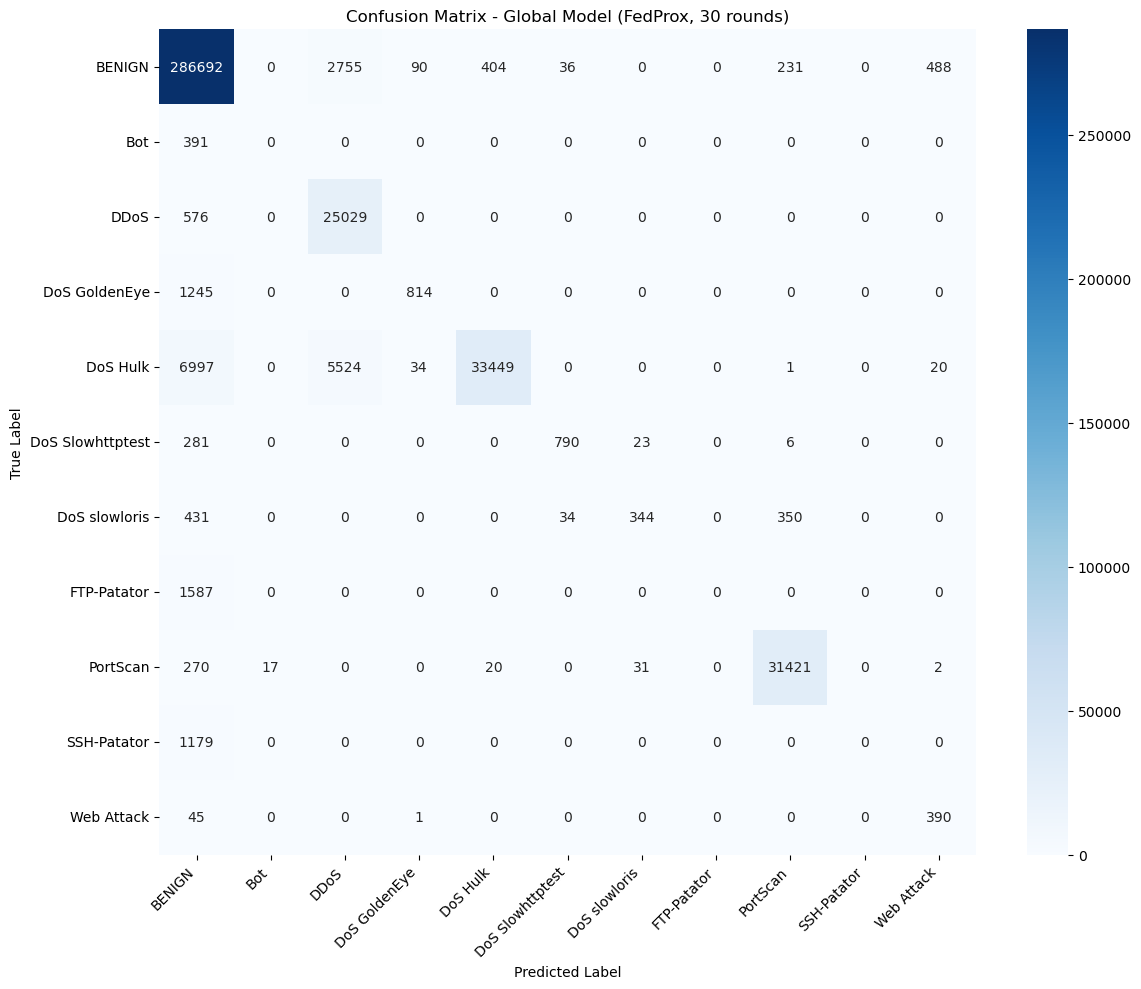

Confusion matrix tersimpan.


In [9]:
# confusion matrix global model
cm = confusion_matrix(all_labels, all_preds, labels=present_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=present_names,
    yticklabels=present_names
)
plt.title('Confusion Matrix - Global Model (FedProx, 30 rounds)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/confusion_matrix_global.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix tersimpan.")

In [10]:
# tabel perbandingan hasil standalone vs global FL
# standalone menunjukkan batas atas performa per node di data lokalnya
# global FL menunjukkan kemampuan deteksi lintas domain serangan
print("=" * 65)
print(f"{'Model':<25} {'Macro F1':>10} {'Keterangan'}")
print("=" * 65)
print(f"{'Node 1 Standalone':<25} {0.9909:>10.4f}  Hanya lihat Brute Force")
print(f"{'Node 2 Standalone':<25} {0.9855:>10.4f}  Hanya lihat DoS")
print(f"{'Node 3 Standalone':<25} {0.8594:>10.4f}  Hanya lihat DDoS/Web/Bot")
print(f"{'Global FL (FedProx)':<25} {0.5735:>10.4f}  Lihat semua kelas")
print("=" * 65)
print("\nCatatan: Standalone tidak bisa deteksi kelas dari node lain.")
print("Global FL bisa deteksi semua kelas meski Macro F1 lebih rendah.")

Model                       Macro F1 Keterangan
Node 1 Standalone             0.9909  Hanya lihat Brute Force
Node 2 Standalone             0.9855  Hanya lihat DoS
Node 3 Standalone             0.8594  Hanya lihat DDoS/Web/Bot
Global FL (FedProx)           0.5735  Lihat semua kelas

Catatan: Standalone tidak bisa deteksi kelas dari node lain.
Global FL bisa deteksi semua kelas meski Macro F1 lebih rendah.
